In [ ]:
# =============================================================
# Nombre del archivo: muu_metrics_bcs_train.py
# Autora: Mónica Monserrat Martínez Vásquez
# Fecha de creación: 28-10-2025
# Última edición: 05-11-2025
#
# Descripción:
#   Entrenamiento de un modelo CNN para estimar BCS (regresión) a partir
#   de imágenes de ganado. Incluye preparación de datos, data augmentation,
#   entrenamiento con callbacks (checkpoint y TensorBoard), evaluación en
#   test y visualización de resultados.
#
# Dependencias: os, numpy, pandas, tensorflow, matplotlib, seaborn, datetime
# =============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, math, random, pathlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau, TensorBoard
import tensorflow.keras.backend as K
import datetime


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Configuración y constantes
baseDir='/content/drive/MyDrive/Equipo 5'
#imagesDir = f'{baseDir}/Final Dataset/Images'
imagesDir = f'{baseDir}/Final Dataset/Images'
#imagesDir = os.path.join(baseDir, 'Data Transformations', 'Cow')
outputDir = f'{baseDir}/4. Modeling'
checkpointDir = f'{outputDir}/Checkpoints'
os.makedirs(checkpointDir, exist_ok=True)

In [ ]:
imageSize    = (512, 512) #800,1000
seed         = 42
batchSize    = 32
valTestSplit = 0.30

In [ ]:
# Descubrimiento de clases
subdirs = sorted([
    d for d in os.listdir(imagesDir)
    if os.path.isdir(os.path.join(imagesDir, d))])

try:
  classNames = sorted(subdirs, key=lambda s: float(s))
except ValueError as e:
  raise ValueError(f"Valores numericos, revisar: {subdirs}") from e

In [ ]:
bcsValues = [float(c) for c in classNames]
print("Clases detectadas (BCS):", bcsValues)

Clases detectadas (BCS): [2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0]


In [ ]:
# Carga de datasets (TFDS)
trainDataset = tf.keras.utils.image_dataset_from_directory(
    imagesDir,
    labels='inferred',
    label_mode='int',
    class_names=classNames,
    color_mode='rgb',
    batch_size=batchSize,
    image_size=imageSize,
    shuffle=True,
    seed=seed,
    validation_split=valTestSplit,
    subset='training'
)


Found 628 files belonging to 13 classes.
Using 440 files for training.


In [ ]:
valTestDataset = tf.keras.utils.image_dataset_from_directory(
    imagesDir,
    labels='inferred',
    label_mode='int',
    class_names=classNames,
    color_mode='rgb',
    batch_size=batchSize,
    image_size=imageSize,
    shuffle=True,
    seed=seed,
    validation_split=valTestSplit,
    subset='validation'
)

Found 628 files belonging to 13 classes.
Using 188 files for validation.


In [ ]:
# Conversión a etiquetas de regresión
bcsLookupTable = tf.constant(bcsValues, dtype=tf.float32)

In [ ]:
@tf.function
def putRegressionLabels(images, classIndices):
  """
    Convierte índices de clase (enteros) a etiquetas de regresión (float BCS).

    Args:
        images (tf.Tensor): Lote de imágenes (B,H,W,C).
        classIndices (tf.Tensor): Índices de clase (enteros).

    Returns:
        Tuple[tf.Tensor, tf.Tensor]: (images, labels_float_reshaped)
    """
    labels = tf.gather(bcsLookupTable, classIndices)
    labels = tf.expand_dims(labels , axis=-1)
    return images, labels

trainRegDataset = trainDataset.map(
  putRegressionLabels, num_parallel_calls=tf.data.AUTOTUNE)
valTestRegDataset = valTestDataset.map(
  putRegressionLabels,  num_parallel_calls=tf.data.AUTOTUNE)

TypeError: in user code:

    File "/tmp/ipython-input-380948412.py", line 3, in putRegressionLabels  *
        labels = tf.gather(bcsLookupTable, classIndices)

    TypeError: Value passed to parameter 'indices' has DataType float32 not in list of allowed values: int16, int32, int64


In [ ]:
def splitValidationAndTest(dataset):
  """
    Divide en partes iguales el dataset de validación original para
    obtener: validación y prueba (50/50).

    Nota:
        Requiere cardinalidad finita. Si retorna -2 (desconocida), considera
        materializar o definir un tamaño fijo previamente.

    Args:
        dataset (tf.data.Dataset): dataset a dividir.

    Returns:
        Tuple[tf.data.Dataset, tf.data.Dataset]: (val, test)
    """
    datasetSize = dataset.cardinality().numpy()
    halfSize = datasetSize // 2
    valDataset  = dataset.take(halfSize)
    testDataset = dataset.skip(halfSize)
    return valDataset, testDataset

valRegDataset, testRegDataset = splitValidationAndTest(valTestRegDataset)

In [ ]:
# Preprocesamiento y augmentación
dataAugmentationLayer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.1),
], name="dataAugmentation")

rescaleLayer = tf.keras.layers.Rescaling(1./255, name="rescaleLayer")

In [ ]:
def augmentThenScale(images, labels):
    """

    images = dataAugmentationLayer(images, training=True)
    images = rescaleLayer(images)
    return images, labels

In [ ]:
def onlyScale(images, labels):
  """
    Escalado 1/255 (validación y prueba).

    Args:
        images (tf.Tensor): imágenes.
        labels (tf.Tensor): etiquetas (BCS).

    Returns:
        Tuple[tf.Tensor, tf.Tensor]
    """
    images = rescaleLayer(images)
    return images, labels

In [ ]:
autoTune = tf.data.AUTOTUNE

trainDataset = (trainRegDataset
           .shuffle(8 * batchSize, seed=seed, reshuffle_each_iteration=True)
           .map(augmentThenScale, num_parallel_calls=autoTune)
           .prefetch(autoTune))

valDataset = (valRegDataset
         .map(onlyScale, num_parallel_calls=autoTune)
         .prefetch(autoTune))

testDataset = (testRegDataset
          .map(onlyScale, num_parallel_calls=autoTune)
          .prefetch(autoTune))

In [ ]:
# Chequeo rápido de tamaños
def countBatches(dataset):
  """
    Cuenta el número de batches en un tf.data.Dataset.

    Args:
        dataset (tf.data.Dataset): dataset.

    Returns:
        int: número de batches.
    """
    return sum(1 for _ in dataset)

print("Batches -> Train:", countBatches(trainDataset),
      "| Val:", countBatches(valDataset),
      "| Test:", countBatches(testDataset))

sampleImages, sampleLabels = next(iter(trainDataset))
print("Sample batch:",
      sampleImages.shape,
      sampleLabels.shape,
      sampleLabels[:8].numpy().ravel()
     )

Batches -> Train: 14 | Val: 3 | Test: 3
Sample batch: (32, 512, 512, 3) (32, 1) [3.   3.25 4.25 3.5  3.   2.5  2.5  3.25]


In [ ]:
# Modelo
def buildBcsCnnModel(inputShape):
  """
    Construye una CNN simple para regresión de BCS.

    Args:
        inputShape (tuple): forma de la entrada (H, W, C).

    Returns:
        tf.keras.Model: modelo compilable.
    """
  model = tf.keras.Sequential([
      layers.Conv2D(32, kernel_size=3, padding='same', activation='relu',
                    kernel_regularizer=regularizers.l2(
                        1e-4), input_shape=inputShape),
      layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
      layers.MaxPooling2D((2, 2)),
      layers.Dropout(0.25),
      layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
      layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
      layers.MaxPooling2D((2, 2)),
      layers.Dropout(0.25),
      layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
      layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
      layers.MaxPooling2D((2, 2)),
      layers.Dropout(0.4),
      layers.Flatten(),
      layers.Dense(256, activation='relu'),
      layers.Dropout(0.4),
      layers.Dense(128, activation='relu'),
      layers.Dense(1, activation='linear', name='bcs_output')
      ])
  return model

inputShape = (512, 512, 3)
model = buildBcsCnnModel(inputShape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 512, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 512, 512, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 524288)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   134,217,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bcs_output (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,538,017 (513.22 MB)

 Trainable params: 134,538,017 (513.22 MB)

 Non-trainable params: 0 (0.00 B)

## Métricas

In [ ]:
# Métricas personalizadas
def mae(yTrue, yPred):
  """Mean Absolute Error (promedio |yTrue - yPred|)."""
  return tf.reduce_mean(tf.abs(yTrue - yPred))

def bias(yTrue, yPred):
  """Sesgo promedio (yPred - yTrue)."""
  return tf.reduce_mean(yPred - yTrue)

def variance(yTrue, yPred):
  """
  Varianza de las predicciones (respecto a su media).
  Nota: no es varianza del error, sino de yPred.
  """
  meanPred = tf.reduce_mean(yPred)
  return tf.reduce_mean(tf.square(yPred - meanPred))

def accuracyWithinHalfBcs(yTrue, yPred):
  """Proporción de predicciones con error absoluto <= 0.5 BCS."""
  absError  = tf.abs(yTrue - yPred)
  return tf.reduce_mean(tf.cast(absError  <= 0.5, tf.float32))

## Compilar

In [ ]:
# Compilación y callbacks
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss='mae',
    metrics=[mae, bias, variance, accuracyWithinHalfBcs]
)

In [ ]:
# Rutas de guardado
checkpointPath = os.path.join(checkpointDir, "bcsCnnWeights.weights.h5")
logsDir = os.path.join(
    outputDir, "logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

# Guardar sólo los pesos
checkpointCallback = ModelCheckpoint(
    filepath=checkpointPath,
    save_weights_only=True,
    save_best_only=True,
    monitor='val_mae',
    mode='min',
    verbose=1
)

In [ ]:
# Detener si el modelo deja de mejorar
earlyStoppingCallback = EarlyStopping(
    monitor='val_mae',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
tensorboardCallback = TensorBoard(log_dir=logsDir)
callbacksList = [checkpointCallback, tensorboardCallback]

## Entrenamiento

In [ ]:
# Entrenamiento
epochs = 30

history = model.fit(
    trainDataset,
    validation_data=valDataset,
    epochs=epochs,
    callbacks=callbacksList,
    verbose=1
)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy_within_half_bcs: 0.3893 - bias: -0.1114 - loss: 0.7672 - mae: 0.7676 - variance: 0.3344
Epoch 1: val_mae did not improve from 1.78866
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy_within_half_bcs: 0.3898 - bias: -0.1081 - loss: 0.7677 - mae: 0.7681 - variance: 0.3346 - val_accuracy_within_half_bcs: 0.0312 - val_bias: -2.0410 - val_loss: 2.0415 - val_mae: 2.0410 - val_variance: 0.0873
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy_within_half_bcs: 0.3864 - bias: -0.0931 - loss: 0.7529 - mae: 0.7518 - variance: 0.2641
Epoch 2: val_mae did not improve from 1.78866
14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy_within_half_bcs: 0.3866 - bias: -0.0891 - loss: 0.7523 - mae: 0.7511 - variance: 0.2630 - val_accuracy_within_half_bcs: 0.0417 - val_bias: -1.9092 - val_loss: 1.9098 - val_mae: 1.9092 - val_variance: 0.1018
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy_within_half_bcs: 0.3841 - bias: -0.180

## Evaluación final

In [ ]:
print("\nEvaluación final en conjunto de prueba:")
results = model.evaluate(testDataset, verbose=1)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


Evaluación final en conjunto de prueba:
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy_within_half_bcs: 0.0686 - bias: -1.7392 - loss: 1.7441 - mae: 1.7393 - variance: 0.0639
loss: 1.6742
compile_metrics: 1.6651


## Guardado de modelo completo final (.keras)

In [ ]:
finalModelPath = os.path.join(outputDir, "MuuMetricsBcsModel.keras")
model.save(finalModelPath)
print(f"\nModelo completo guardado en: {finalModelPath}")

KeyboardInterrupt: 

## Visualización del aprendizaje

In [ ]:
yTrue, yPred = [], []

for batchImages, batchLabels in testDataset:
    batchPreds = model.predict(batchImages)
    yTrue.extend(batchLabels.numpy().ravel())
    yPred.extend(batchPreds.ravel())

yTrue = np.array(yTrue)
yPred = np.array(yPred)

yPredRounded = np.round(yPred * 4) / 4

maeValue = np.mean(np.abs(yTrue - yPred))
biasValue = np.mean(yPred - yTrue)
varianceValue = np.var(yPred)
accuracyHalf = np.mean(np.abs(yTrue - yPred) <= 0.5)

print(f"\n----> Resultados globales:")
print(f"MAE: {maeValue:.4f}")
print(f"Bias: {biasValue:.4f}")
print(f"Varianza: {varianceValue:.4f}")
print(f"Accuracy ±0.5 BCS: {accuracyHalf*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

----> Resultados globales:
MAE: 1.6955
Bias: -1.6954
Varianza: 0.0719
Accuracy ±0.5 BCS: 6.52%


### Gráfica de Aprendizaje

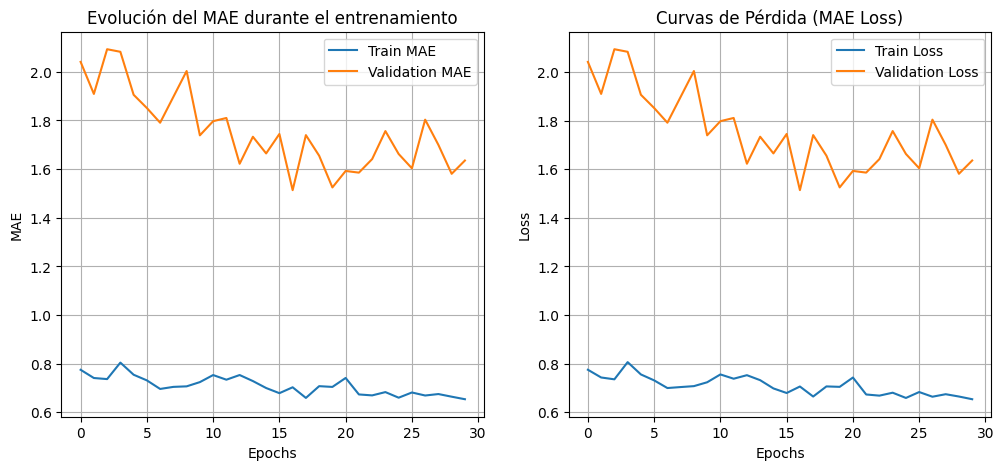

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Evolución del MAE durante el entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Curvas de Pérdida (MAE Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
history = model.fit(
    trainDataset,
    validation_data=valDataset,
    epochs=epochs,
    callbacks=callbacksList,
    verbose=1
)

Epoch 1/2
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy_within_half_bcs: 0.3183 - bias: -0.0854 - loss: 0.8669 - mae: 0.8659 - variance: 0.4128
Epoch 1: val_mae improved from 2.18254 to 2.14880, saving model to /content/drive/MyDrive/Equipo 5/4. Modeling/Checkpoints/bcsCnnWeights.weights.h5
14/14 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy_within_half_bcs: 0.3191 - bias: -0.0802 - loss: 0.8664 - mae: 0.8653 - variance: 0.4104 - val_accuracy_within_half_bcs: 0.0104 - val_bias: -2.1488 - val_loss: 2.1493 - val_mae: 2.1488 - val_variance: 0.1232
Epoch 2/2
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy_within_half_bcs: 0.4145 - bias: -0.2435 - loss: 0.7847 - mae: 0.7792 - variance: 0.3112
Epoch 2: val_mae improved from 2.14880 to 1.78866, saving model to /content/drive/MyDrive/Equipo 5/4. Modeling/Checkpoints/bcsCnnWeights.weights.h5
14/14 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy_within_half_bcs: 0.4130 - bias: -0.2386 - loss: 0.7851 - mae: 0.7798 - variance: 0.3120 - val_accuracy_

### Dispersión Real vs Predicho

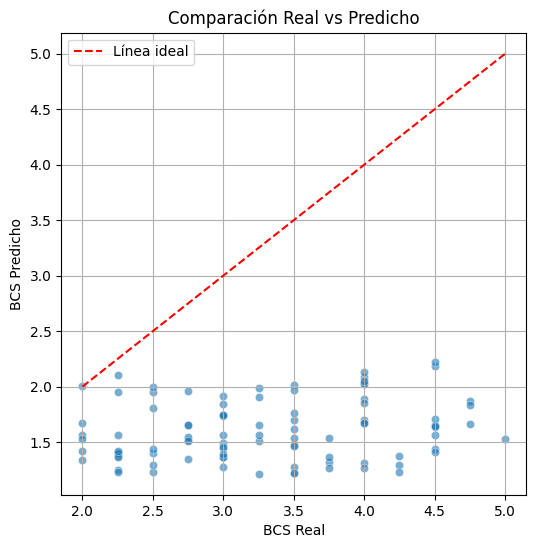

In [ ]:
import seaborn as sns
plt.figure(figsize=(6, 6))
sns.scatterplot(x=yTrue, y=yPred, alpha=0.6)
plt.plot([min(yTrue), max(yTrue)],
         [min(yTrue), max(yTrue)],
         'r--', label='Línea ideal'
         )
plt.xlabel('BCS Real')
plt.ylabel('BCS Predicho')
plt.title('Comparación Real vs Predicho')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


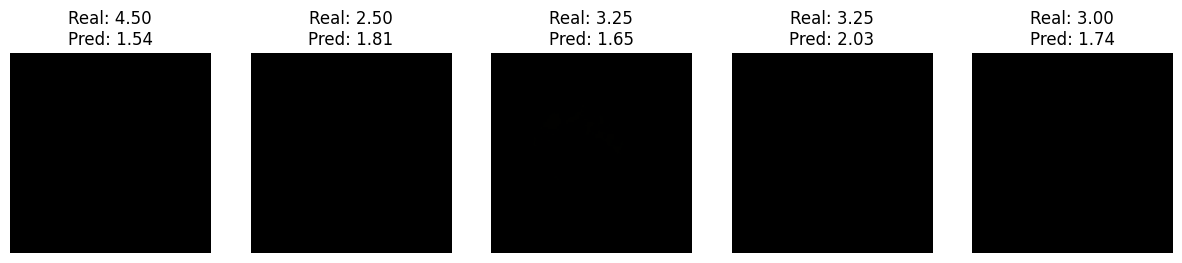

In [ ]:
def showExamples(images, trueValues, predValues, n=5):
  """
  Muestra n ejemplos de imágenes con BCS real vs. predicho.
  Args:
      images (tf.Tensor): batch de imágenes escaladas.
      trueValues (np.ndarray): etiquetas reales (BCS).
      predValues (np.ndarray): predicciones del modelo (BCS).
      n (int): número de ejemplos a mostrar.
  """
  plt.figure(figsize=(15, 3))
  for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(
              f"Real: {trueValues[i]:.2f}\nPred: {predValues[i]:.2f}"
              )
    plt.axis("off")
plt.show()
sampleImages, sampleLabels = next(iter(testDataset))
samplePreds = model.predict(sampleImages)

showExamples(sampleImages,
             sampleLabels.numpy().ravel(),
             samplePreds.ravel()
            )